##### top

# FMP modelling for Figure 5 (Vegetarian)

This notebook runs Bayesian models on Dataset 5 (dataset with Vegetarian condition) that is described in the article to assess interaction between perception and memory difficulty levels in the FMP. We fit the following formulas to mean score within the condition. Throughout the notebook, I use `task` as a term for memory difficulty levels (M, UD, FD-e, FD-v), `difficulty` as a term for perceptual difficulty levels (1, 2, 3), and `userID` as a variable denoting individual participants.


* Model task and difficulty interaction with user as a random effect. Equation:
    * _correct_flt ~ task * difficulty + (1|userID)_
* Model task and difficulty as main effects without interaction with user as a random effect. Equation:
    * _correct_flt ~ task + difficulty + (1|userID)_



We model mean accuracy per participant per condition.


* [Models](#Models)
* [Plot results](#Plot-results)
* [Compare all data](#Compare-all-data)
* [Save the inference](#Save-the-inference)


In [1]:
import os, sys
import pickle
from os.path import join as opj
import arviz as az
import bambi as bmb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-darkgrid")
SEED = 7355608


# Importing module for functions
functions_modul =  "./functions"
sys.path.insert(0, functions_modul)

# import all processing and plotting functions
from bayesian_modelling_functions import fit_model, print_model

path_general = "../"
path_data = opj(path_general, "Data", "datasets")
path_inference_data = opj(path_general, "Data", "model_inference_data")


# set the numer of CPU
num_cpu = min(4, os.cpu_count()-1)
print(f'We will have {num_cpu} cores.\n')

path_dic = {
#     'dataset_1' : opj(path_data, 'FMP_dataset_1.csv'),
#     'dataset_2': opj(path_data, 'FMP_dataset_2.csv'),
#     'dataset_3': opj(path_data, 'FMP_dataset_3.csv'),
#     'concat_datasets_123': opj(path_data, 'FMP_concat_datasets_123.csv'),
#     'dataset_4': opj(path_data, 'FMP_dataset_4.csv'),
    'dataset_5': opj(path_data, 'FMP_dataset_5.csv'),
}


# load all dataframes
df_dic = {}

# only selected cols
select_cols = ['stim1', 'stim2', 'target', 'RT', 'userID', 'difficulty', 'levels', 'task', 'correct_flt', 'order']


for f in path_dic.keys():   
    if f=="first_pilot":
        df_dic[f] = pd.read_csv(path_dic[f], usecols=(set(['correct_check'])|set(select_cols))-set(['correct_flt']))
        # convert boolean answers to floats to be able to do mean
        df_dic[f]['correct_flt'] = df_dic[f].correct_check.astype(float)
    elif 'longitudinal_' in f:
        df_dic[f] = pd.read_csv(path_dic[f], usecols=select_cols+['target_loc', 'target_loc_simple'])
    else:
        df_dic[f] = pd.read_csv(path_dic[f], usecols=select_cols)
    
    df_dic[f]["Experiment"] = f
        

    # clean
    df_dic[f].reset_index(drop=True, inplace=True)
    
    if 'Unnamed: 0' in df_dic[f].columns:
        df_dic[f].drop('Unnamed: 0', inplace=True, axis=1)
        
    
    # find low performing participants
    tt = df_dic[f].loc[df_dic[f]['task'].isin(['face matching', 'perc', 'perception'])].groupby(['userID', 'difficulty']).correct_flt.mean()

    drop_ptc = tt[tt<=0.5].reset_index().userID.values
    print(f'\nIn {f} dropping {len(drop_ptc)} participants for low accuracy in FM.')
    print(tt[tt<=0.5])

    # and remove them
    df_dic[f] = df_dic[f].loc[~df_dic[f]['userID'].isin(drop_ptc)]
    # clean up
    drop_ptc, tt = None, None
    
    print(f"\nThere is now N={df_dic[f]['userID'].unique().size} participants in {f}.")



#####
# rename the levels
rename_tasks_dic = {'perception':'Matching', 'perc':'Matching', 'blank':'Unfilled Delay', 'faces':'Filled Delay - emotions', 
                    'math':'Filled Delay - math', 'veg':'Filled Delay - veg'}

# define orders
hue_order = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions']
hue_order_math = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions', 'Filled Delay - math']
hue_order_veg = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions', 'Filled Delay - veg']



# rename the memory task labels in the df
for f in df_dic.keys():
    if f=='noise':
        continue
    df_dic[f]['task'] = df_dic[f]['task'].map(rename_tasks_dic).fillna(df_dic[f]['task'])


We will have 4 cores.


In dataset_5 dropping 0 participants for low accuracy in FM.
Series([], Name: correct_flt, dtype: float64)

There is now N=83 participants in dataset_5.


In [2]:
# select only specific datasets and prepare them
datasets2fit = ['dataset_5']

df_dic_fit = {}


for f in datasets2fit:
    data=None
    
    # groupby and make means for ptc and condition
    data = df_dic[f].groupby(['userID', 'task', 'difficulty'], observed=False).correct_flt.mean().reset_index()

    # convert all variables to categories
    # categorical_cols = data.columns[data.dtypes == object].tolist() + ['difficulty']
    categorical_cols = ['userID', 'task', 'difficulty']
    for col in categorical_cols:
        if col == 'task':
            # specify the order that we want
            data[col] = pd.Categorical(data[col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions', 'Filled Delay - veg'], ordered=True)
            #['Unfilled Delay', 'Matching', 'Filled Delay - emotions']
            
            # also do it for the original datasets
            df_dic[f][col] = pd.Categorical(df_dic[f][col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions', 'Filled Delay - veg'], ordered=True)
        else:
            data[col] = data[col].astype("category")
            df_dic[f][col] = df_dic[f][col].astype("category")

    # check
    print('\n',f)
    df_dic[f].info()
        
    # save
    df_dic_fit[f] = data.copy()

# # drop them for now
# data[data.correct_flt.isna()]


 dataset_5
<class 'pandas.core.frame.DataFrame'>
Index: 19920 entries, 0 to 19919
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   userID       19920 non-null  category
 1   target       19920 non-null  object  
 2   stim1        19920 non-null  object  
 3   stim2        19920 non-null  object  
 4   correct_flt  19534 non-null  float64 
 5   RT           19534 non-null  float64 
 6   task         19920 non-null  category
 7   order        19920 non-null  int64   
 8   difficulty   19920 non-null  category
 9   levels       19920 non-null  int64   
 10  Experiment   19920 non-null  object  
dtypes: category(3), float64(2), int64(2), object(4)
memory usage: 1.4+ MB


## Model as means
[top](#top)

In [3]:
model_assumptions = {
    "correct_flt ~ task * difficulty + (1|userID)": "Each user has their own baseline performance, but the effect of task and difficulty is assumed to be the same across all users.",
    "correct_flt ~ task + difficulty + (1|userID)": "Assumes that each user has their own baseline performance, but the effects of task and difficulty are consistent across all users without any interaction between task and difficulty.",
}

# define what we want to run
formulas2run = [
    "correct_flt ~ task * difficulty + (1|userID)",
    "correct_flt ~ task + difficulty + (1|userID)",
]

In [4]:
# define where we will store the results
model_dic_bernoulli = {}
result_dic_bernoulli = {}

for f in df_dic_fit.keys():
    print(f'\nFitting dataset {f}\n')
    # create datasets
    if f not in model_dic_bernoulli.keys():
        model_dic_bernoulli[f] = {}
    if f not in result_dic_bernoulli.keys():
        result_dic_bernoulli[f] = {}
    
    for formula in formulas2run:
        print(f'\nFitting formula {formula}\n')
    
        model_dic_bernoulli[f][formula], result_dic_bernoulli[f][formula] = fit_model(formula, df_dic_fit[f], categorical_cols,
                                                                                      num_cpu=num_cpu, check_priors=False, sample_priors=False)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:36

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.


In [5]:
model_dic_bernoulli[f][formulas2run[0]]

       Formula: correct_flt ~ task * difficulty + (1|userID)
        Family: gaussian
          Link: mu = identity
  Observations: 996
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.7405, sigma: 0.7299)
            task ~ Normal(mu: [0. 0. 0.], sigma: [0.8952 0.8952 0.8952])
            difficulty ~ Normal(mu: [0. 0.], sigma: [0.8223 0.8223])
            task:difficulty ~ Normal(mu: [0. 0. 0. 0. 0. 0.], sigma: [1.4025 1.4025 1.4025 1.4025 1.4025
                1.4025])
        
        
        Group-level effects
            1|userID ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.7299))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.155)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

In [6]:
model_dic_bernoulli[f][formulas2run[1]]

       Formula: correct_flt ~ task + difficulty + (1|userID)
        Family: gaussian
          Link: mu = identity
  Observations: 996
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.7405, sigma: 0.6714)
            task ~ Normal(mu: [0. 0. 0.], sigma: [0.8952 0.8952 0.8952])
            difficulty ~ Normal(mu: [0. 0.], sigma: [0.8223 0.8223])
        
        Group-level effects
            1|userID ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.6714))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.155)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

### check priors

Sampling: [1|userID_sigma, Intercept, difficulty, sigma, task, task:difficulty]


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'task\nMatching'}>,
        <Axes: title={'center': 'task\nFilled Delay - emotions'}>],
       [<Axes: title={'center': 'task\nFilled Delay - veg'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>,
        <Axes: title={'center': 'task:difficulty\nMatching, 2'}>],
       [<Axes: title={'center': 'task:difficulty\nMatching, 3'}>,
        <Axes: title={'center': 'task:difficulty\nFilled Delay - emotions, 2'}>,
        <Axes: title={'center': 'task:difficulty\nFilled Delay - emotions, 3'}>,
        <Axes: title={'center': 'task:difficulty\nFilled Delay - veg, 2'}>],
       [<Axes: title={'center': 'task:difficulty\nFilled Delay - veg, 3'}>,
        <Axes: title={'center': '1|userID_sigma'}>, <Axes: >, <Axes: >]],
      dtype=object)

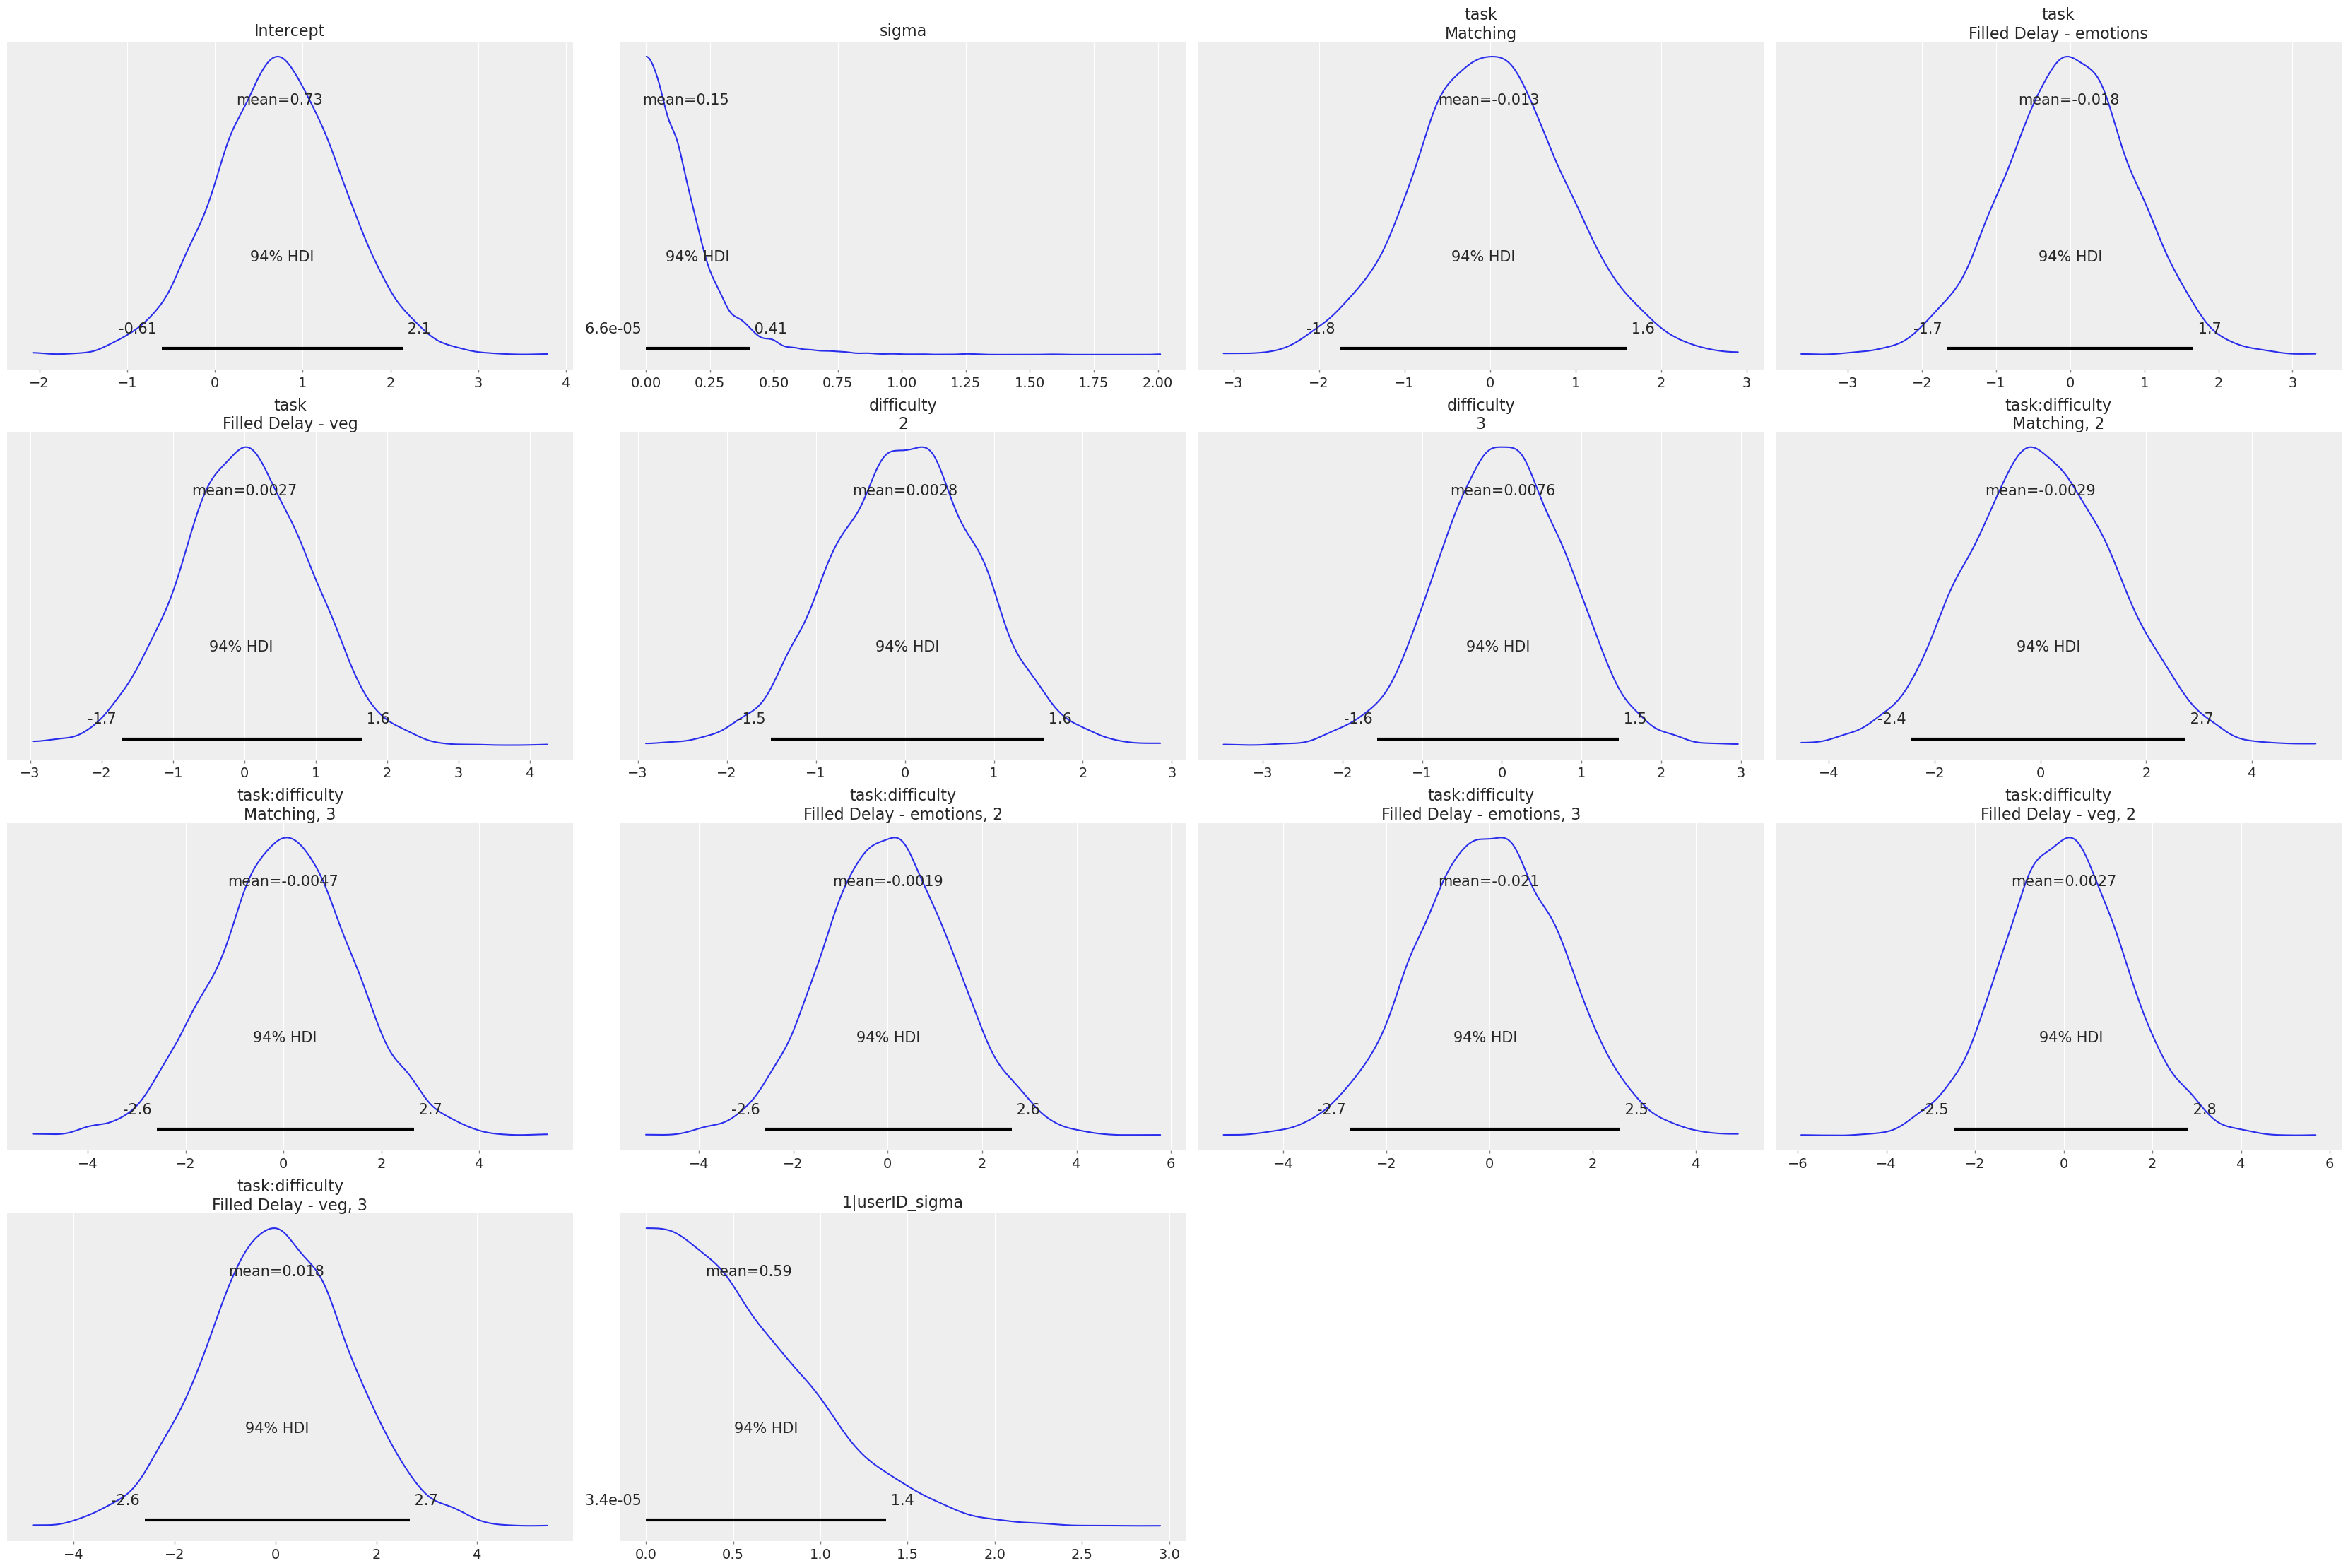

In [7]:
model_dic_bernoulli[f][formulas2run[0]].plot_priors()

Sampling: [1|userID_sigma, Intercept, difficulty, sigma, task]


array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'task\nMatching'}>,
        <Axes: title={'center': 'task\nFilled Delay - emotions'}>],
       [<Axes: title={'center': 'task\nFilled Delay - veg'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>,
        <Axes: title={'center': '1|userID_sigma'}>]], dtype=object)

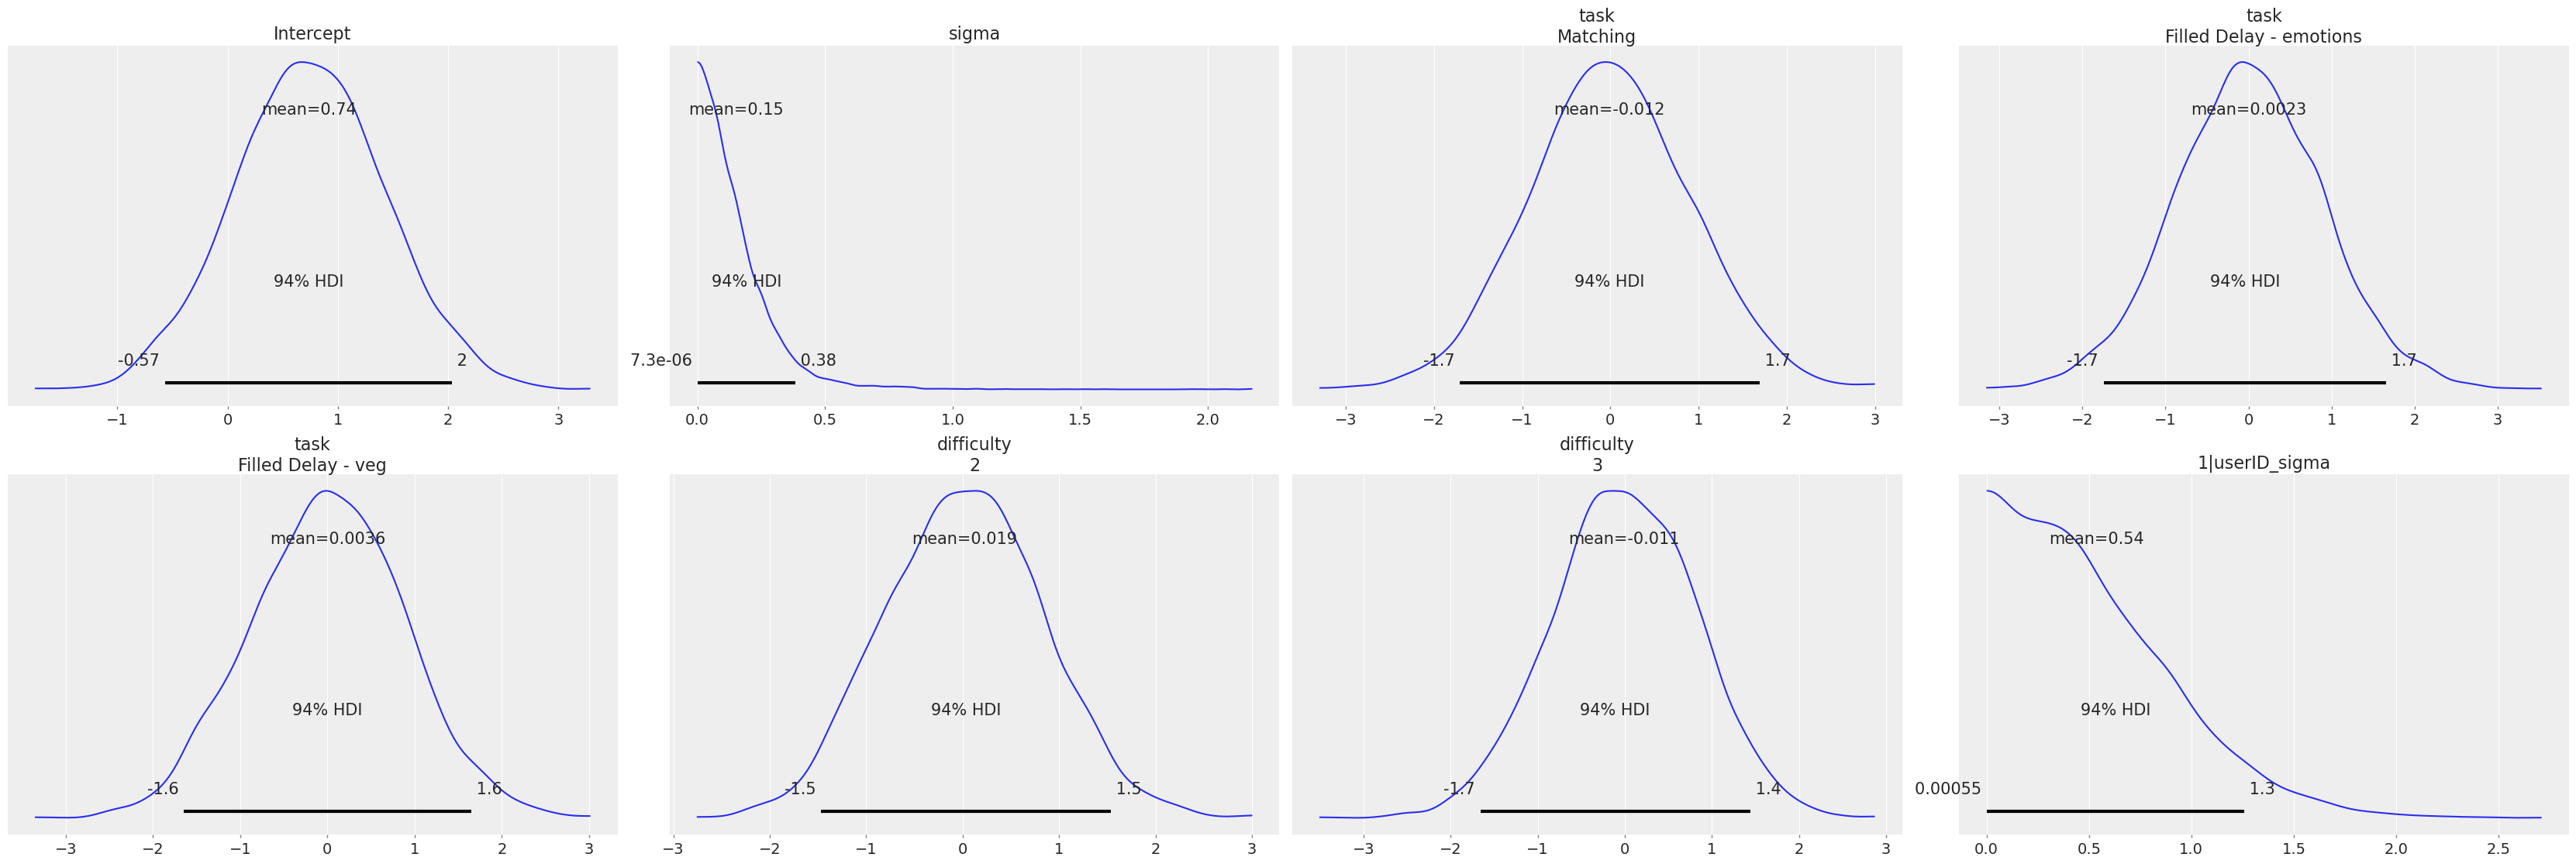

In [8]:
model_dic_bernoulli[f][formulas2run[1]].plot_priors()

### check posterior

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': 'task\nMatching'}>,
        <Axes: title={'center': 'task\nFilled Delay - emotions'}>,
        <Axes: title={'center': 'task\nFilled Delay - veg'}>]],
      dtype=object)

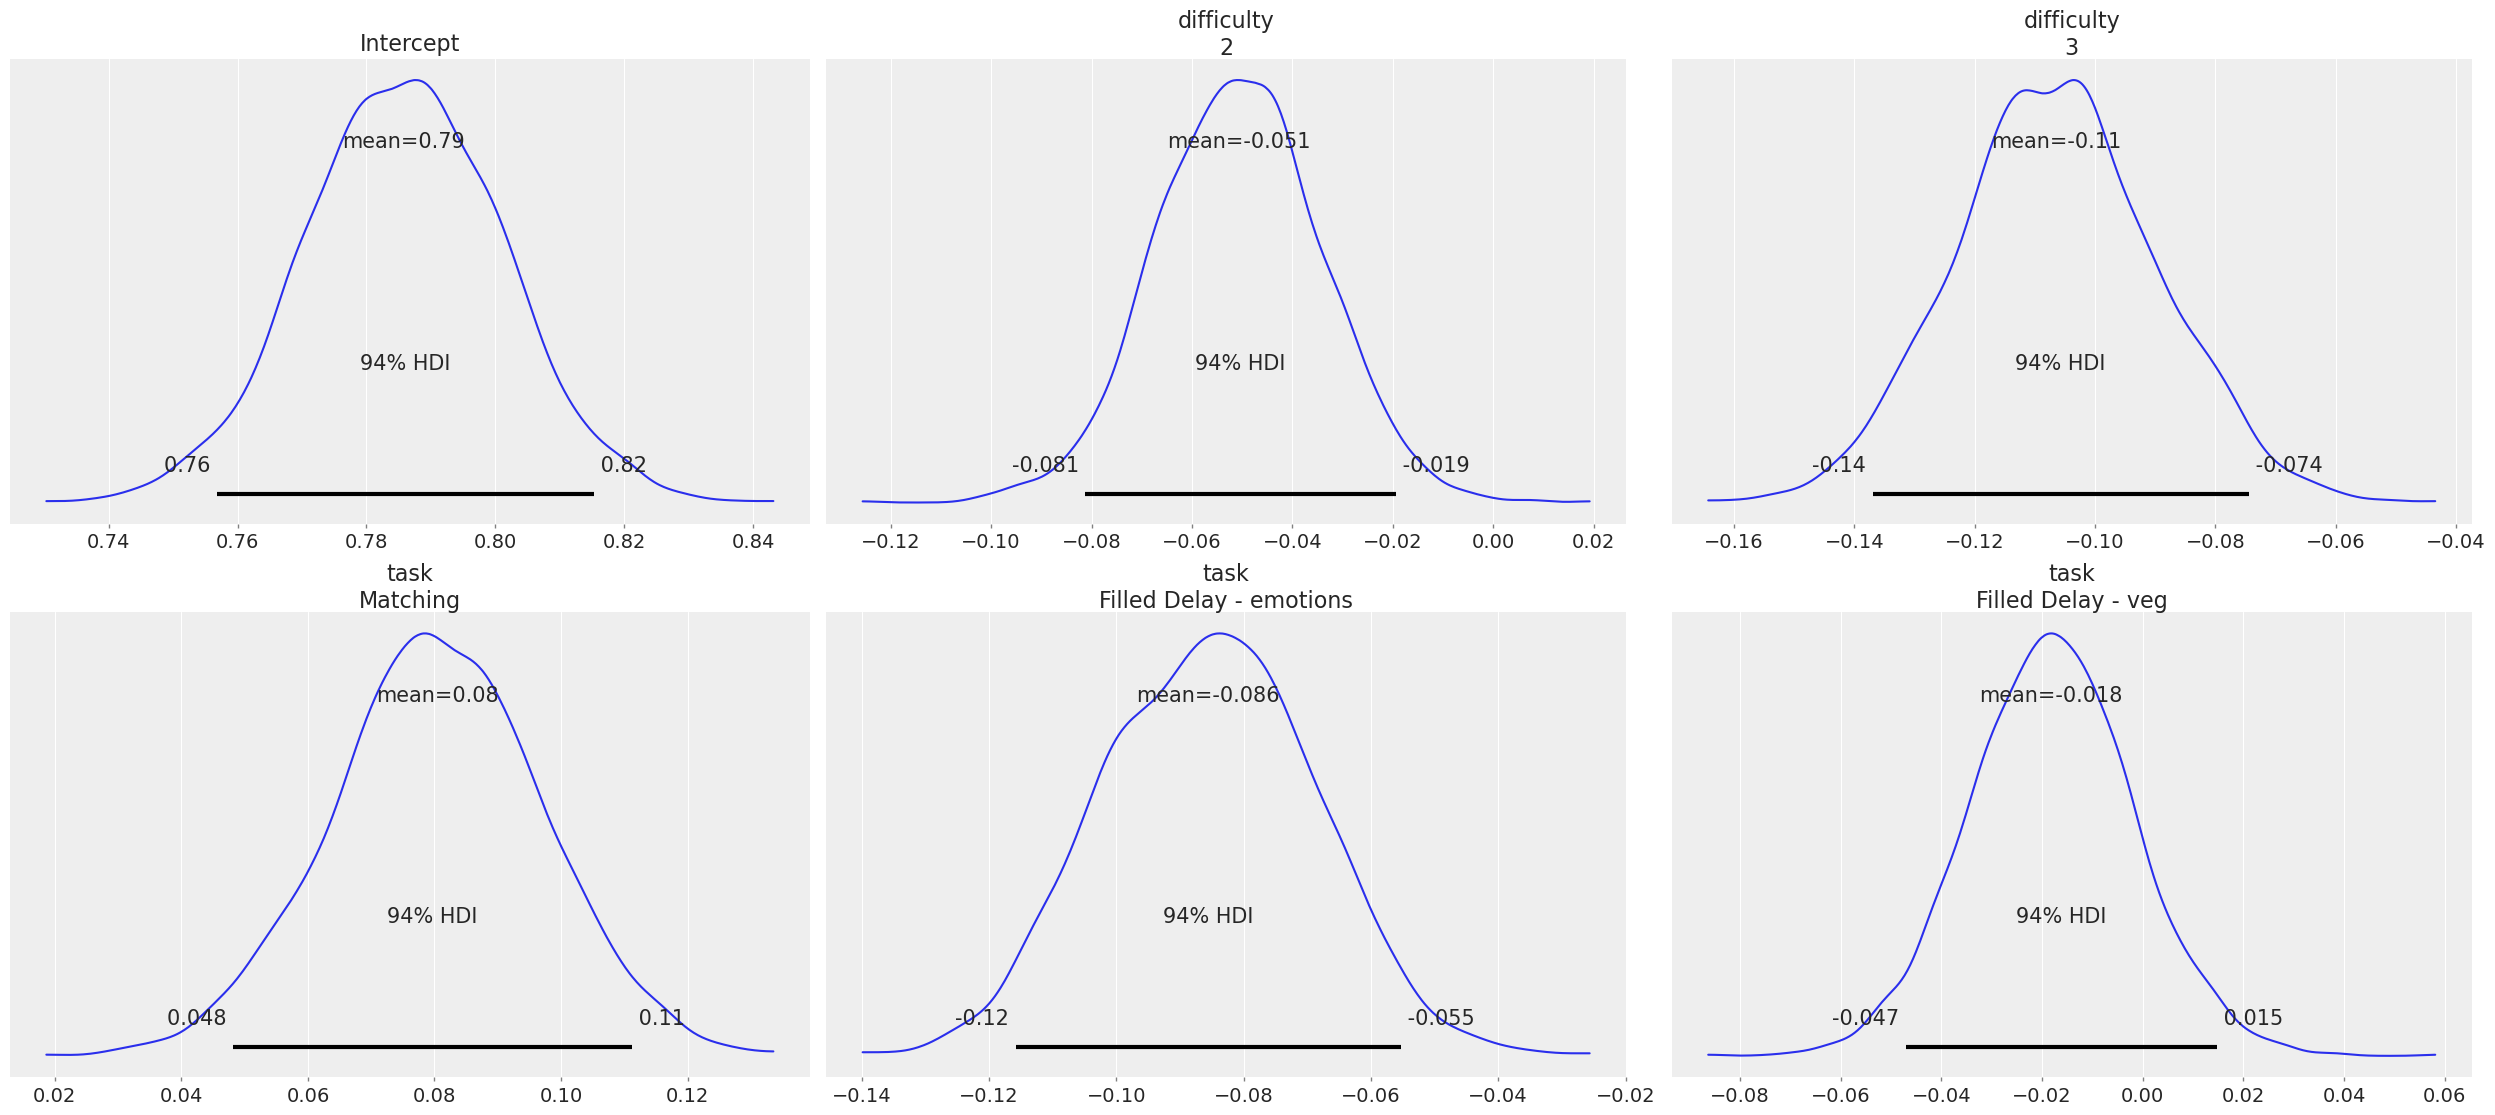

In [9]:
az.plot_posterior(result_dic_bernoulli[f][formulas2run[0]], 
                  var_names=['Intercept', 'difficulty', 'task'],#, 'task:difficulty'],
                  hdi_prob=.94)

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'difficulty\n2'}>,
        <Axes: title={'center': 'difficulty\n3'}>],
       [<Axes: title={'center': 'task\nMatching'}>,
        <Axes: title={'center': 'task\nFilled Delay - emotions'}>,
        <Axes: title={'center': 'task\nFilled Delay - veg'}>]],
      dtype=object)

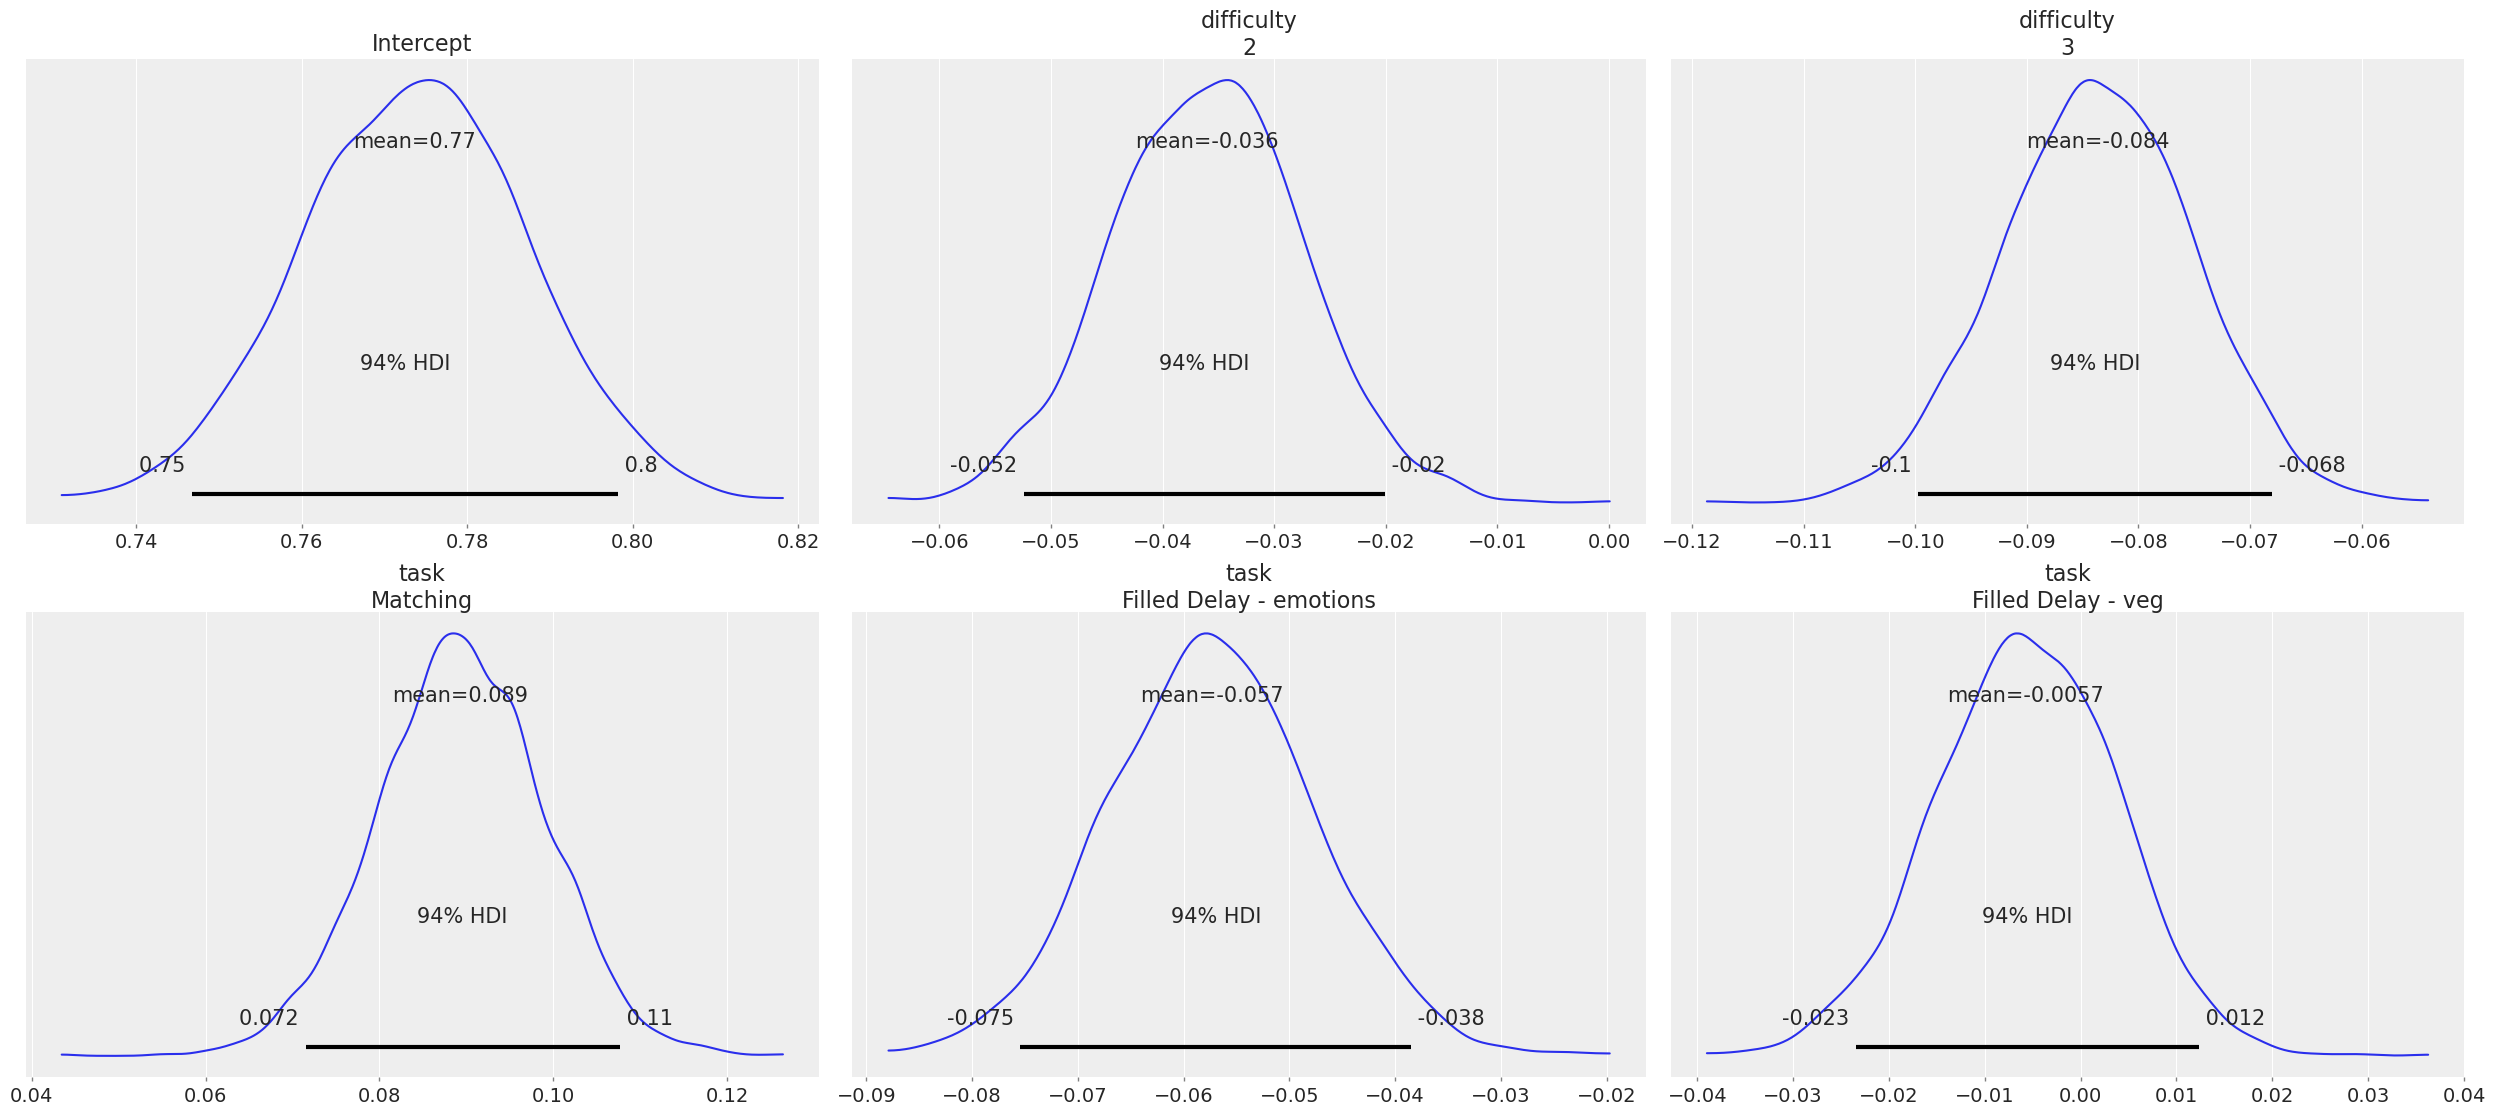

In [10]:
az.plot_posterior(result_dic_bernoulli[f][formulas2run[1]], 
                  var_names=['Intercept', 'difficulty', 'task'],#, 'task:difficulty'],
                  hdi_prob=.94)

---
## Plot results

## FMP dataset 6 -- with Vege condition
[top](#top)


Dataset: dataset_5

Fitting formula correct_flt ~ task * difficulty + (1|userID)



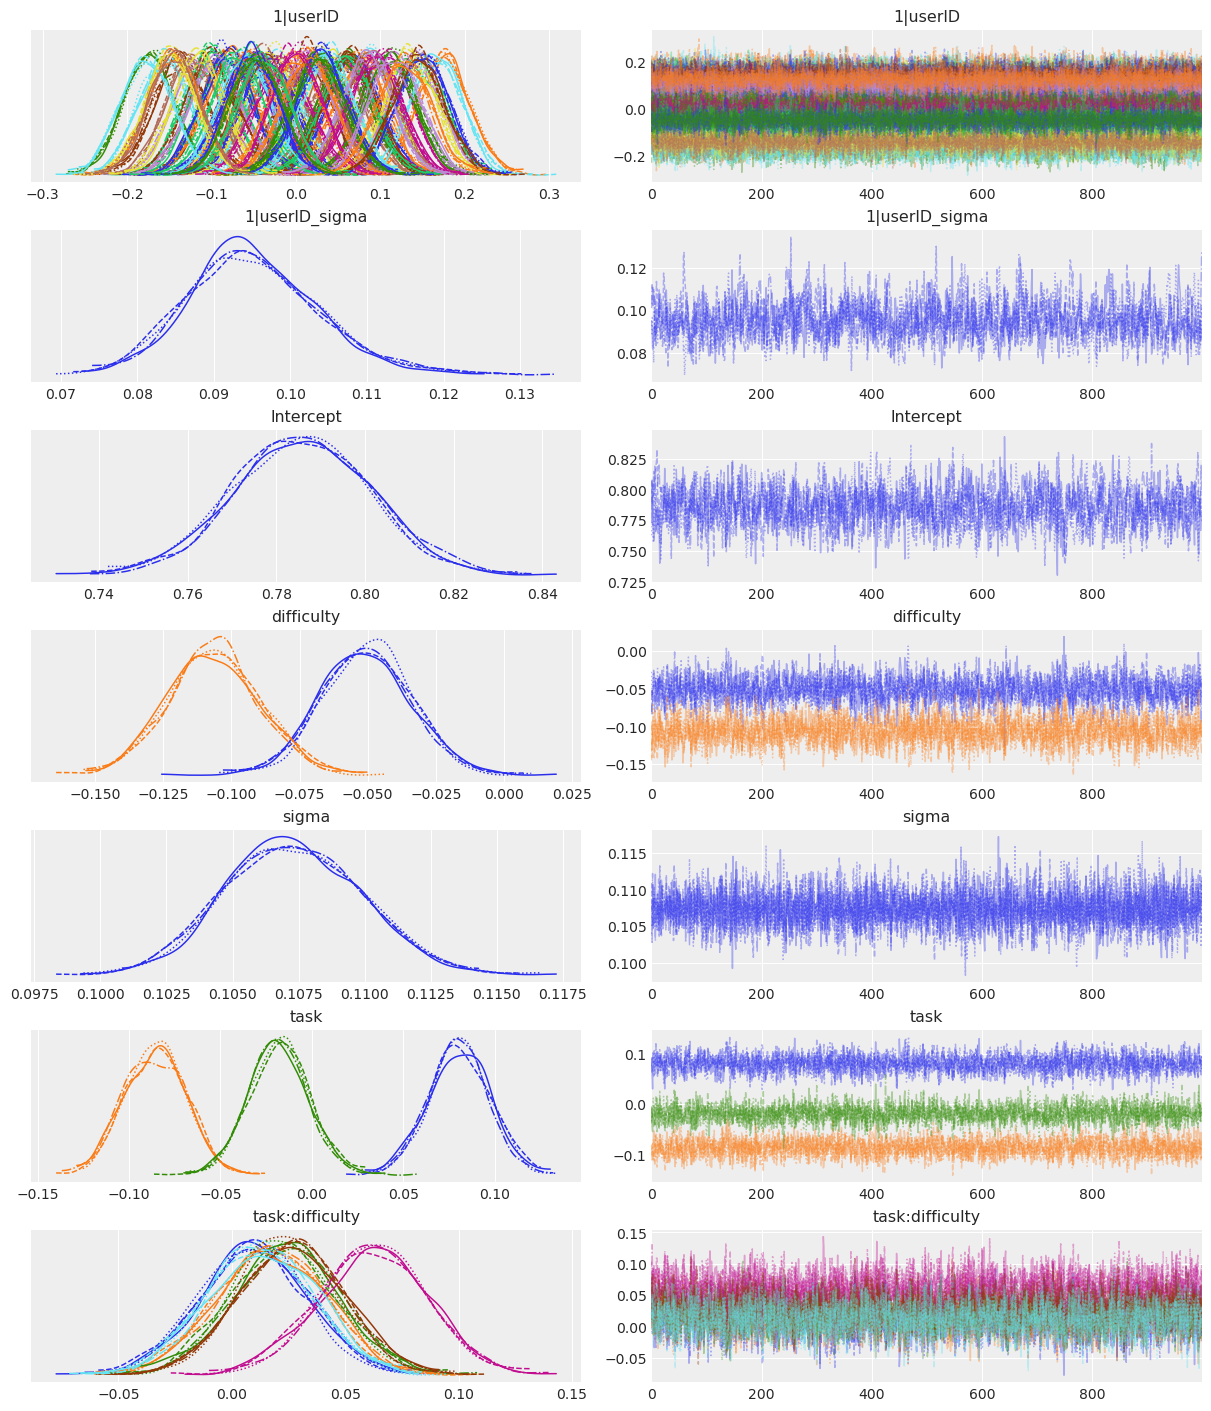

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1009]  0.022  0.032  -0.036    0.083      0.000      0.0    4557.0   
1|userID[s_102]  -0.058  0.031  -0.116    0.000      0.000      0.0    4160.0   
1|userID[s_1022]  0.061  0.032   0.002    0.121      0.000      0.0    4758.0   
1|userID[s_1023]  0.107  0.030   0.053    0.164      0.000      0.0    4143.0   
1|userID[s_1024] -0.137  0.031  -0.194   -0.077      0.000      0.0    4339.0   
1|userID[s_1088]  0.086  0.031   0.031    0.145      0.000      0.0    4276.0   
1|userID[s_1091]  0.039  0.031  -0.019    0.096      0.000      0.0    4784.0   
1|userID[s_1096] -0.104  0.030  -0.156   -0.044      0.000      0.0    3800.0   
1|userID[s_1101] -0.050  0.031  -0.105    0.014      0.000      0.0    4032.0   
1|userID[s_1124]  0.049  0.032  -0.013    0.107      0.000      0.0    4128.0   
1|userID[s_113]  -0.060  0.032  -0.118    0.003      0.000      0.0    5005.0   
1|userID[s_1143]  0.175  0.0

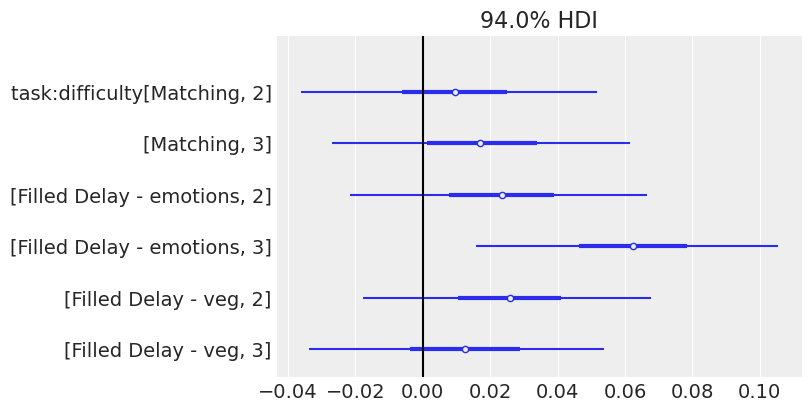

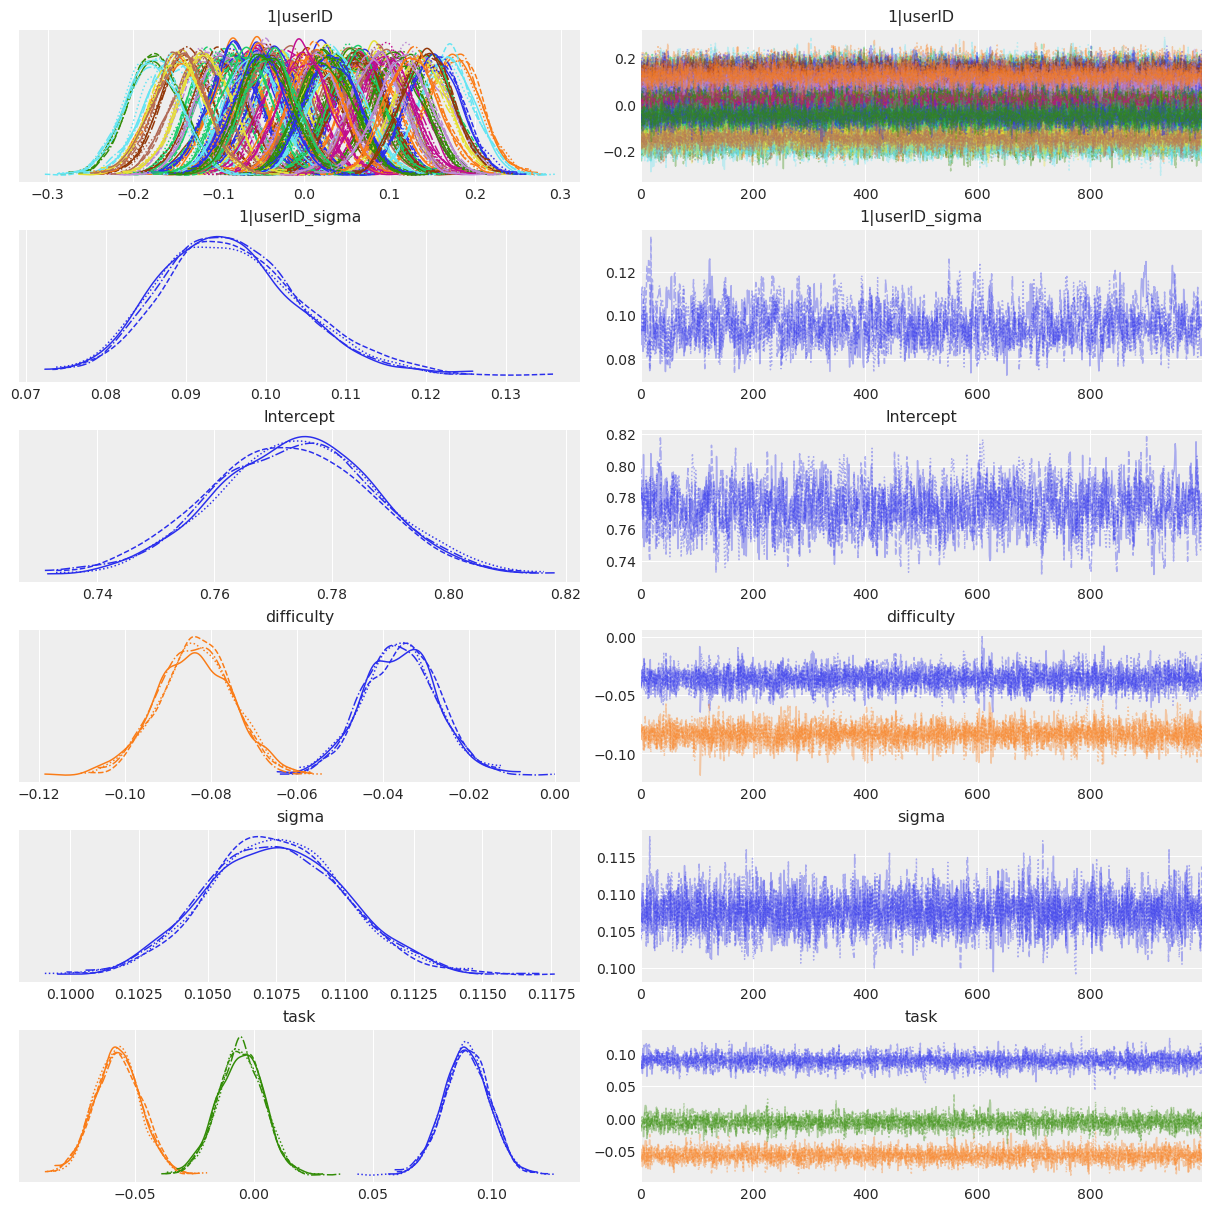

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1009]  0.022  0.032  -0.037    0.085      0.001    0.001    3565.0   
1|userID[s_102]  -0.058  0.030  -0.115   -0.003      0.000    0.000    3677.0   
1|userID[s_1022]  0.061  0.032  -0.003    0.115      0.001    0.000    3208.0   
1|userID[s_1023]  0.106  0.031   0.047    0.161      0.000    0.000    3822.0   
1|userID[s_1024] -0.138  0.031  -0.191   -0.076      0.001    0.000    3736.0   
1|userID[s_1088]  0.086  0.031   0.028    0.144      0.001    0.000    3396.0   
1|userID[s_1091]  0.039  0.032  -0.025    0.094      0.001    0.000    3361.0   
1|userID[s_1096] -0.105  0.031  -0.165   -0.049      0.001    0.000    3243.0   
1|userID[s_1101] -0.050  0.031  -0.108    0.008      0.001    0.000    3325.0   
1|userID[s_1124]  0.049  0.031  -0.007    0.112      0.001    0.000    2934.0   
1|userID[s_113]  -0.060  0.031  -0.122   -0.005      0.001    0.000    3384.0   
1|userID[s_1143]  0.174  0.0

In [11]:
f = 'dataset_5'

print(f'Dataset: {f}')
for formula in formulas2run:
    print(f'\nFitting formula {formula}\n')
    print_model(model_dic_bernoulli[f][formula], result_dic_bernoulli[f][formula])

### Compare all data
[top](#top)

dataset_5 

                                              rank    elpd_loo      p_loo  \
correct_flt ~ task + difficulty + (1|userID)     0  765.364515  78.675149   
correct_flt ~ task * difficulty + (1|userID)     1  764.599212  83.682799   

                                              elpd_diff    weight         se  \
correct_flt ~ task + difficulty + (1|userID)   0.000000  0.566136  24.682957   
correct_flt ~ task * difficulty + (1|userID)   0.765303  0.433864  24.751813   

                                                   dse  warning scale  
correct_flt ~ task + difficulty + (1|userID)  0.000000    False   log  
correct_flt ~ task * difficulty + (1|userID)  3.335993    False   log  



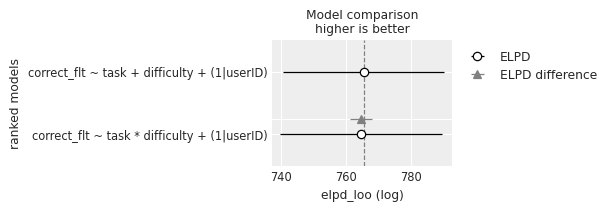

In [12]:
df_compare_formulas_bernoulli = {}
for f in result_dic_bernoulli.keys():
    print(f, '\n')
    df_compare_formulas_bernoulli[f] = az.compare(result_dic_bernoulli[f])
    
    print(df_compare_formulas_bernoulli[f])
    
    az.plot_compare(df_compare_formulas_bernoulli[f], insample_dev=False);

    
    print()
# df_compare_formulas_bernoulli[f]

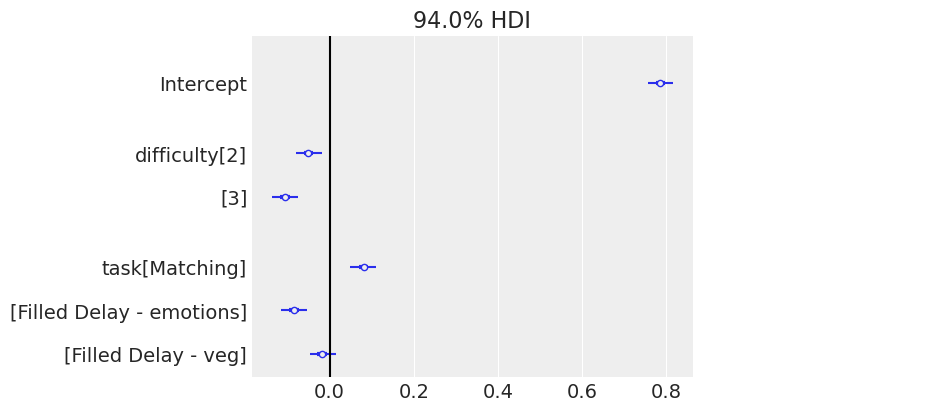

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
az.plot_forest(
    result_dic_bernoulli['dataset_5']['correct_flt ~ task * difficulty + (1|userID)'],
#     model_names=['Dataset 4'],
    var_names=["Intercept", "difficulty", "task"],
    combined=True,
    ax=ax
)

ax.axvline(0, c='k')

# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legend_handles
ax.legend(handles, labels, loc="lower right", bbox_to_anchor=(1.56, -.02), ncols=1)
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()



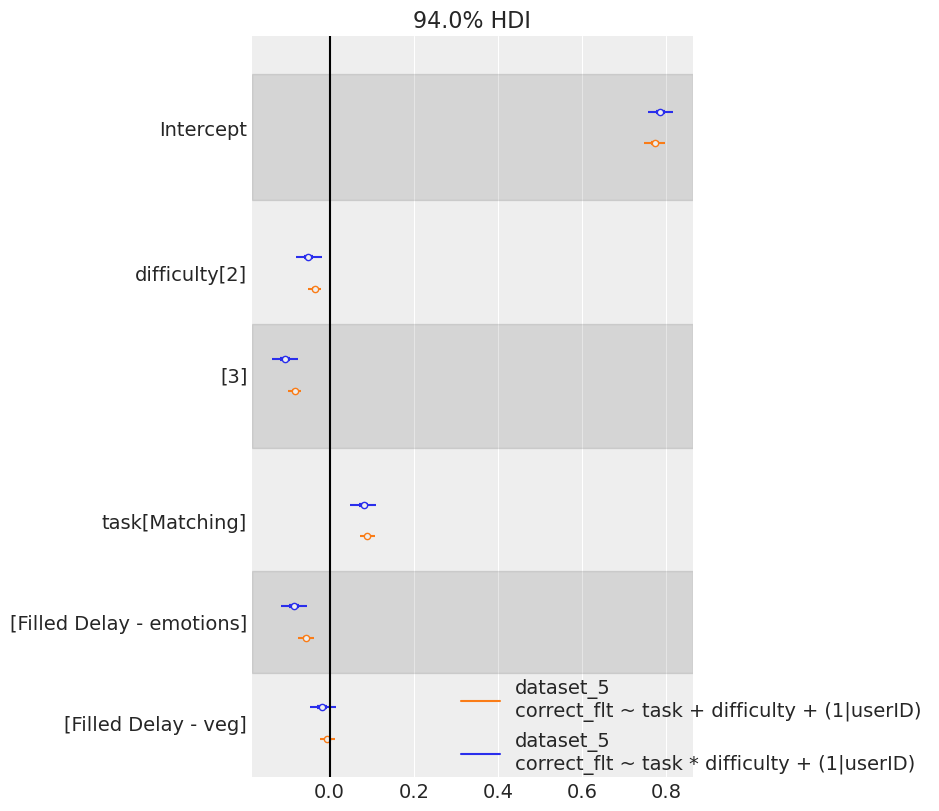

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
az.plot_forest(
    list(result_dic_bernoulli['dataset_5'].values()),
    model_names=[f'{f}\n{formula}' for f in result_dic_bernoulli.keys() for formula in formulas2run],
    var_names=["Intercept", "difficulty", "task"],
    combined=True,
    ax=ax
)

ax.axvline(0, c='k')

# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legend_handles
ax.legend(handles, labels, loc="lower right", bbox_to_anchor=(1.56, -.02), ncols=1)
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()



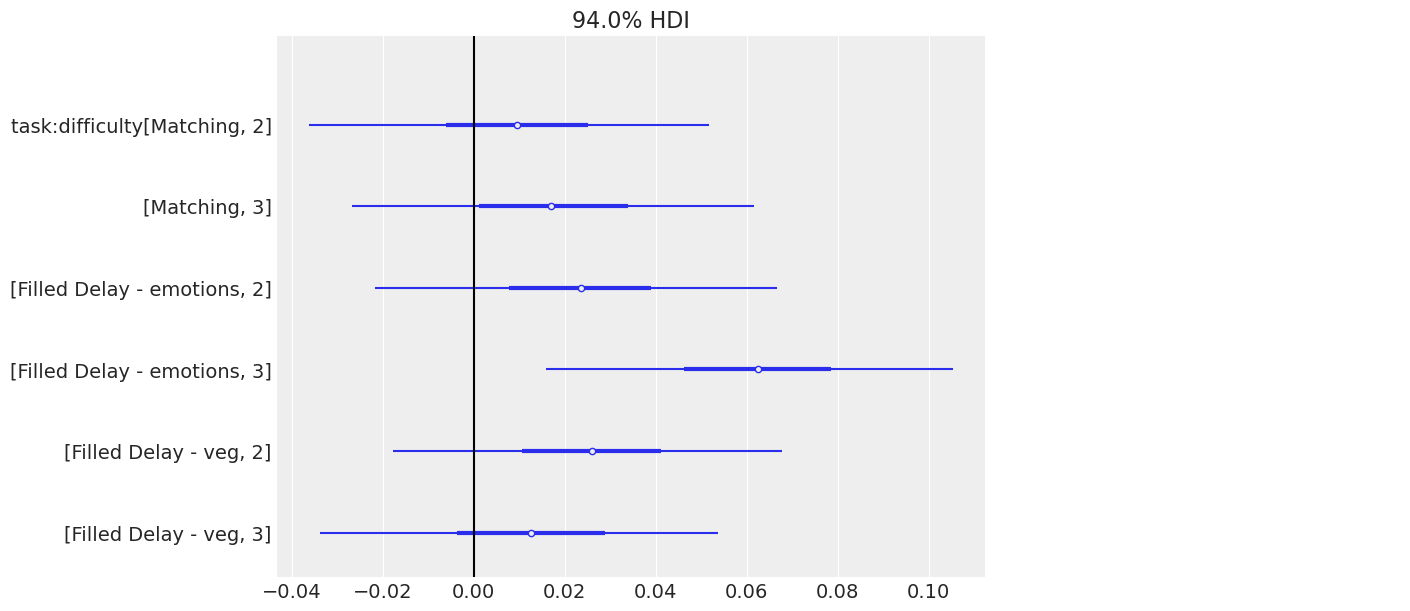

In [15]:

fig, ax = plt.subplots(figsize=(12, 6))
az.plot_forest(
    (list(result_dic_bernoulli['dataset_5'].values())
    )[::2],
#     model_names=[f'{f}' for f in result_dic_bernoulli.keys()],
    var_names=["task:difficulty"],
    combined=True,
#     figsize=(12, 10)
    ax=ax
);

ax.axvline(0, c='k')

# plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
# # plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
# plt.show()


# manually adjust the legend, there is some weird bug
legend = ax.get_legend()
labels = [] if legend is None else [str(x._text) for x in legend.texts]
handles = [] if legend is None else legend.legend_handles
ax.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.6, 1))
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()

### Run some predictions
[top](#top)

In [16]:
# interactions = ['face matching, 2', 'face matching, 3', 'veg, 2', 'veg, 3', 'interference, 2', 'interference, 3']
interactions = ['Matching, 2', 'Matching, 3', 'Filled Delay - veg, 2', 'Filled Delay - veg, 3', 'Filled Delay - emotions, 2', 'Filled Delay - emotions, 3']
fm2, fm3, v2, v3, i2, i3 = [result_dic_bernoulli[f]['correct_flt ~ task * difficulty + (1|userID)'].posterior["task:difficulty"].sel({"task:difficulty_dim":tsk}) for tsk in interactions]



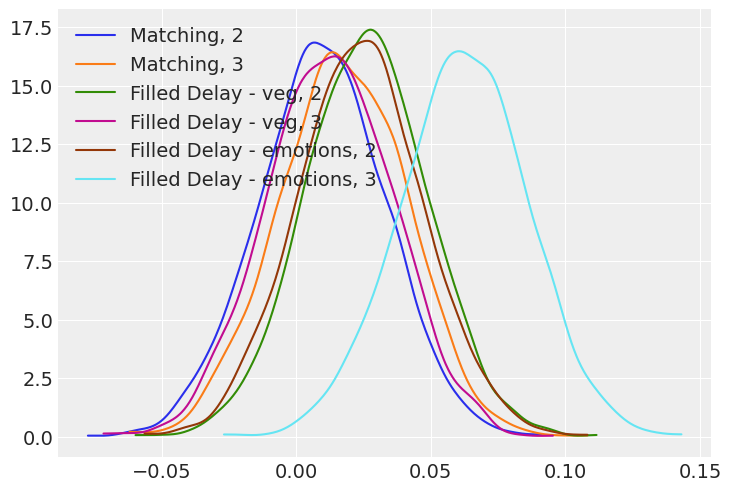

In [17]:
_, ax = plt.subplots()
for idx, x in enumerate([fm2, fm3, v2, v3, i2, i3]):
    az.plot_dist(x, label=x["task:difficulty_dim"].item(), plot_kwargs={"color": f"C{idx}"}, ax=ax)
ax.legend(loc="upper left");

In [18]:
# Probability that the FM slope is less than 0

print(f"""
Probability that the M slope is less than 0:
level 2: {(fm2 < 0).mean().item()}
level 3: {(fm3 < 0).mean().item()}
""")


Probability that the M slope is less than 0:
level 2: 0.33625
level 3: 0.2375



---

In [19]:
for f in result_dic_bernoulli.keys():

    fm2, fm3, v2, v3, i2, i3 = [result_dic_bernoulli[f]['correct_flt ~ task * difficulty + (1|userID)'].posterior["task:difficulty"].sel({"task:difficulty_dim":tsk}) for tsk in interactions]
    print(f"""
Experiment {f}:
  Probability that the M slope is less than 0:
    level 2: {(fm2 < 0).mean().item()}
    level 3: {(fm3 < 0).mean().item()}
    
  Probability that the FD-v (Vegetarian) slope is less than 0:
    level 2: {(v2 < 0).mean().item()}
    level 3: {(v3 < 0).mean().item()}
    
  Probability that the FD-e slope is less than 0:
    level 2: {(i2 < 0).mean().item()}
    level 3: {(i3 < 0).mean().item()}
    
    """)


Experiment dataset_5:
  Probability that the M slope is less than 0:
    level 2: 0.33625
    level 3: 0.2375
    
  Probability that the FD-v (Vegetarian) slope is less than 0:
    level 2: 0.12225
    level 3: 0.30075
    
  Probability that the FD-e slope is less than 0:
    level 2: 0.15425
    level 3: 0.004
    
    


### Save the inference
[top](#top)

It could be possible to use this:
```
result_dic_bernoulli['dataset_5']['correct_flt ~ task * difficulty + (1|userID)'].to_netcdf()
```

but it doesn't preserve the dictionary, so I use pickle.

In [20]:
# save the dictionary to a pickle file
with open(opj(path_inference_data,'FMP_vege_inference_data_dict.pkl'), 'wb') as f:
    pickle.dump(result_dic_bernoulli['dataset_5'], f)

In [21]:
# # Load the dictionary from the pickle file
# with open(opj(path_inference_data,'FMP_math_inference_data_dict.pkl'), 'rb') as f:
#     loaded_inference_data_dict = pickle.load(f)


In [22]:
%load_ext watermark

%watermark -a 'Jan Kadlec' -nmvu -iv -iv -w -p pytensor


Author: Jan Kadlec

Last updated: Sun Jun 08 2025

Python implementation: CPython
Python version       : 3.12.5
IPython version      : 8.25.0

pytensor: 2.23.0

Compiler    : GCC 12.4.0
OS          : Linux
Release     : 5.14.0-427.42.1.el9_4.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 96
Architecture: 64bit

numpy     : 1.26.4
sys       : 3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:36:51) [GCC 12.4.0]
pandas    : 2.2.2
bambi     : 0.14.0
arviz     : 0.19.0
matplotlib: 3.9.2

Watermark: 2.4.3



[top](#top)